In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import json

In [3]:
image=cv2.imread("image.png")
print(image.shape)

(422, 516, 3)


In [4]:
rgb_image=cv2.cvtColor(image,cv2.COLOR_BGR2RGB)

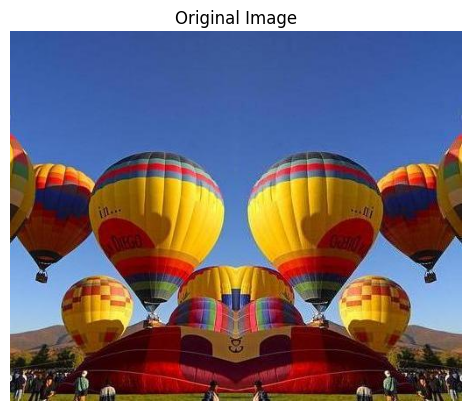

In [5]:
plt.imshow(rgb_image)
plt.title("Original Image")
plt.axis("off")
plt.show()

In [6]:
R=rgb_image[:,:,0]
G=rgb_image[:,:,1]
B=rgb_image[:,:,2]

In [7]:
gray=(0.3*R)+(0.59*G)+(0.11*B)
gray=gray.astype(np.uint8)

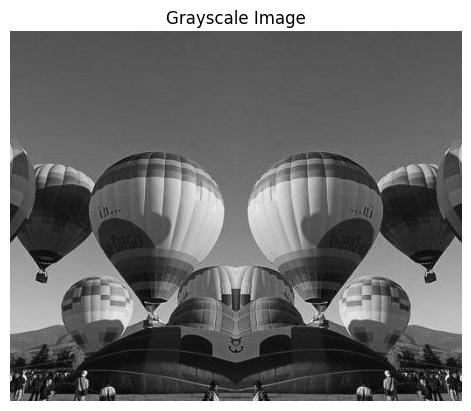

In [8]:
plt.imshow(gray,cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

In [9]:
cv2.imwrite("grayscale_image.jpg",gray)

True

In [10]:
print("Height:",gray.shape[0])
print("Width:",gray.shape[1])

Height: 422
Width: 516


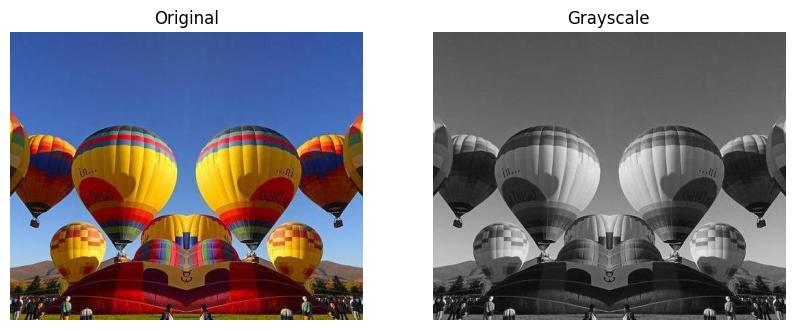

In [11]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(rgb_image)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(gray,cmap="gray")
plt.title("Grayscale")
plt.axis("off")

plt.show()

In [12]:
image_data={
    "Height":int(gray.shape[0]),
    "Width":int(gray.shape[1]),
    "Channels":1,
    "Data Type":str(gray.dtype),
    "Total Pixels":int(gray.shape[0]*gray.shape[1])
}

In [13]:
print(image_data)

{'Height': 422, 'Width': 516, 'Channels': 1, 'Data Type': 'uint8', 'Total Pixels': 217752}


In [14]:
with open("image_data.json","w") as file:
    json.dump(image_data,file,indent=4)

In [15]:
with open("image_data.json","r") as file:
    data=json.load(file)

print(data)

{'Height': 422, 'Width': 516, 'Channels': 1, 'Data Type': 'uint8', 'Total Pixels': 217752}


In [16]:
for key,value in data.items():
    print(key,":",value)

Height : 422
Width : 516
Channels : 1
Data Type : uint8
Total Pixels : 217752


In [17]:
import os

if os.path.exists("image_data.json"):
    print("JSON file saved successfully.")
else:
    print("JSON file not found.")

JSON file saved successfully.


In [18]:
def make_histogram(image,size):

    histogram=np.zeros(size,dtype=int)

    rows=image.shape[0]
    cols=image.shape[1]

    for i in range(rows):
        for j in range(cols):
            pixel=image[i,j]
            histogram[pixel]=histogram[pixel]+1

    return histogram

In [19]:
histogram=make_histogram(gray,256)

In [20]:
print(histogram)

[  67   83   88  100   84  104  126  160  193  193  281  332  509  547
  955 1241 1130 1174 1155 1091 1058 1087 1090 1141 1197 1248 1464 1717
 1729 1538 1297 1235 1051 1040 1179 1249 1456 1579 1545 1553 1313 1283
 1145 1000  960  924  873  892  842  825  843  775  764  703  626  666
  611  561  586  520  611  565  550  553  546  560  503  528  473  441
  479  449  435  454  515  532  587  612  665  769  866 1573 1945 3534
 4224 3763 4154 4115 4883 4001 4059 4749 5192 4167 4260 4159 4066 4311
 3362 3884 3392 3033 3176 3222 2441 2297 2592 2213 1818 1841 1510 1126
  970  702  680  638  581  593  508  471  448  401  418  399  363  409
  388  370  381  399  460  405  408  369  360  332  391  443  375  504
  450  521  539  502  511  503  461  397  437  524  508  636  514  516
  554  552  568  576  570  570  536  509  510  501  497  470  499  395
  486  505  511  416  540  669  639  628  543  449  609  600  527  567
  537  525  610  715  671  616  569  614  587  626  508  436  423  389
  323 

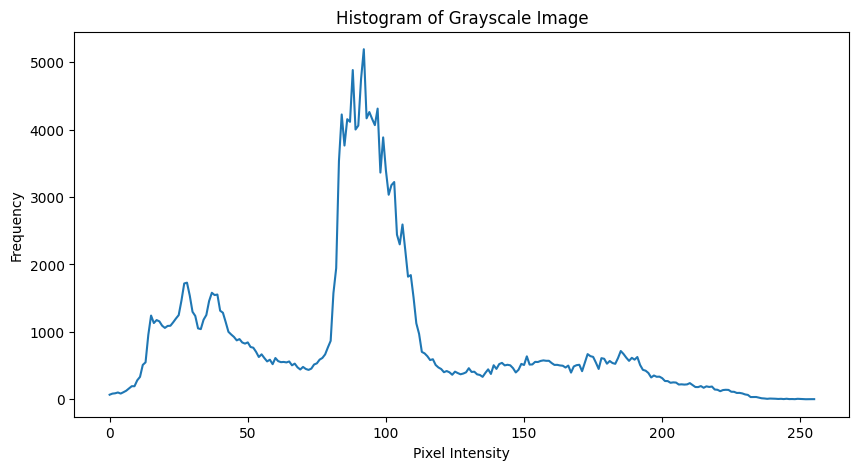

In [21]:
plt.figure(figsize=(10,5))

plt.plot(histogram)

plt.title("Histogram of Grayscale Image")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")

plt.show()

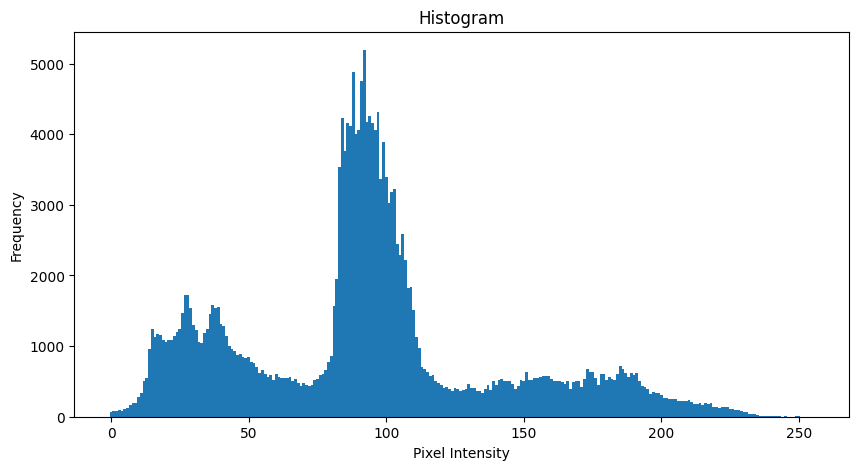

In [22]:
plt.figure(figsize=(10,5))

plt.bar(range(256),histogram,width=1)

plt.title("Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")

plt.show()

In [23]:
print("Maximum Frequency:",np.max(histogram))

Maximum Frequency: 5192


In [24]:
print("Most Frequent Pixel:",np.argmax(histogram))

Most Frequent Pixel: 92


In [25]:
if np.sum(histogram)==gray.shape[0]*gray.shape[1]:
    print("Histogram Verified")
else:
    print("Histogram Error")

Histogram Verified


In [26]:
def cumulative_sum(histogram):

    cdf=np.zeros(len(histogram),dtype=int)

    cdf[0]=histogram[0]

    for i in range(1,len(histogram)):
        cdf[i]=cdf[i-1]+histogram[i]

    return cdf

In [27]:
cdf=cumulative_sum(histogram)

In [28]:
print(cdf)

[    67    150    238    338    422    526    652    812   1005   1198
   1479   1811   2320   2867   3822   5063   6193   7367   8522   9613
  10671  11758  12848  13989  15186  16434  17898  19615  21344  22882
  24179  25414  26465  27505  28684  29933  31389  32968  34513  36066
  37379  38662  39807  40807  41767  42691  43564  44456  45298  46123
  46966  47741  48505  49208  49834  50500  51111  51672  52258  52778
  53389  53954  54504  55057  55603  56163  56666  57194  57667  58108
  58587  59036  59471  59925  60440  60972  61559  62171  62836  63605
  64471  66044  67989  71523  75747  79510  83664  87779  92662  96663
 100722 105471 110663 114830 119090 123249 127315 131626 134988 138872
 142264 145297 148473 151695 154136 156433 159025 161238 163056 164897
 166407 167533 168503 169205 169885 170523 171104 171697 172205 172676
 173124 173525 173943 174342 174705 175114 175502 175872 176253 176652
 177112 177517 177925 178294 178654 178986 179377 179820 180195 180699
 18114

In [29]:
cdf_min=np.min(cdf[cdf>0])

cdf_max=np.max(cdf)

print("Minimum:",cdf_min)
print("Maximum:",cdf_max)

Minimum: 67
Maximum: 217752


In [30]:
equalized=((cdf-cdf_min)*255)/(cdf_max-cdf_min)

equalized=equalized.astype(np.uint8)

In [31]:
equalized_image=np.zeros_like(gray)

rows=gray.shape[0]
cols=gray.shape[1]

for i in range(rows):
    for j in range(cols):
        equalized_image[i,j]=equalized[gray[i,j]]

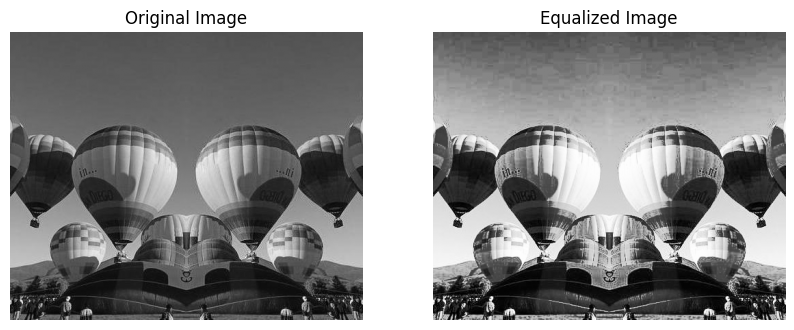

In [32]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(gray,cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(equalized_image,cmap="gray")
plt.title("Equalized Image")
plt.axis("off")

plt.show()

In [33]:
equalized_histogram=make_histogram(equalized_image,256)

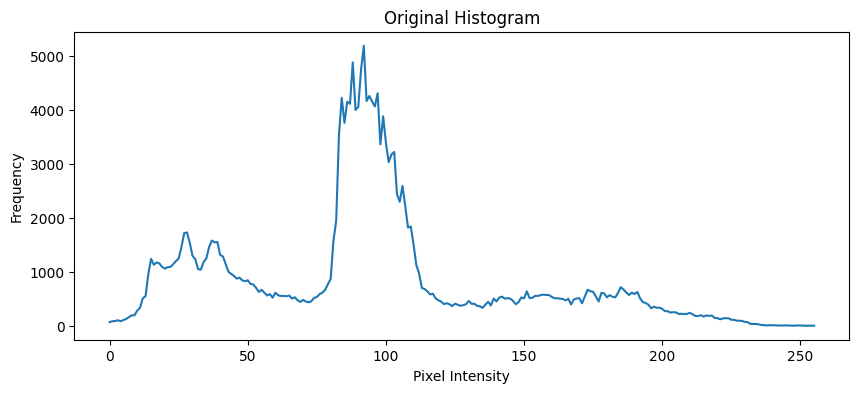

In [34]:
plt.figure(figsize=(10,4))

plt.plot(histogram)

plt.title("Original Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")

plt.show()

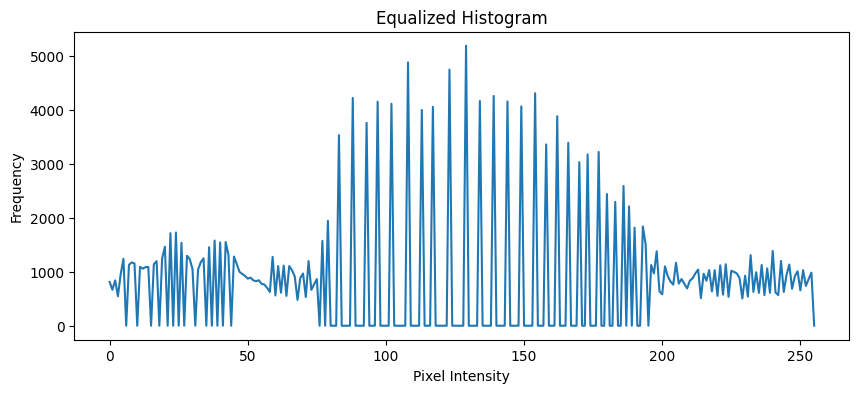

In [35]:
plt.figure(figsize=(10,4))

plt.plot(equalized_histogram)

plt.title("Equalized Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")

plt.show()

In [36]:
cv2.imwrite("equalized_image.jpg",equalized_image)

True

In [37]:
print("Original Shape:",gray.shape)
print("Equalized Shape:",equalized_image.shape)

Original Shape: (422, 516)
Equalized Shape: (422, 516)


In [40]:
image=cv2.imread("lenna.png",0)

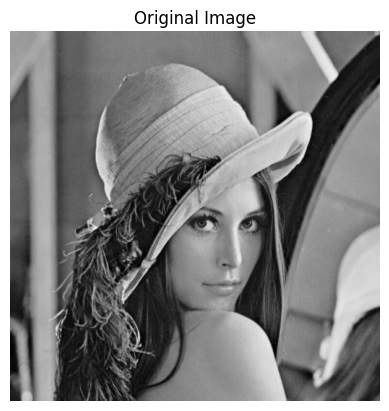

In [41]:
plt.imshow(image,cmap="gray")
plt.title("Original Image")
plt.axis("off")
plt.show()

In [42]:
print("Height:",image.shape[0])
print("Width:",image.shape[1])

Height: 512
Width: 512


In [43]:
resized=cv2.resize(image,(16,16))

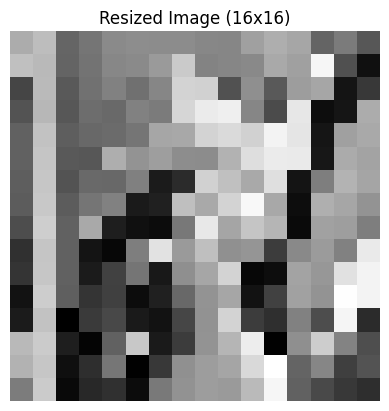

In [44]:
plt.imshow(resized,cmap="gray")
plt.title("Resized Image (16x16)")
plt.axis("off")
plt.show()

In [45]:
kernel=np.array([
    [3,0,3],
    [1,0,1],
    [3,0,3]
])

print(kernel)

[[3 0 3]
 [1 0 1]
 [3 0 3]]


In [46]:
filtered=np.zeros((16,16),dtype=np.float32)

In [47]:
for i in range(1,15):
    for j in range(1,15):

        region=resized[i-1:i+2,j-1:j+2]

        value=np.sum(region*kernel)

        filtered[i,j]=value

In [48]:
filtered=cv2.normalize(filtered,None,0,255,cv2.NORM_MINMAX)

filtered=filtered.astype(np.uint8)

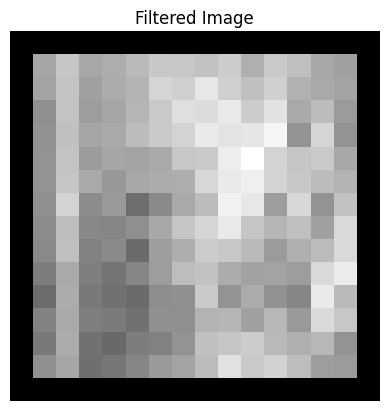

In [49]:
plt.imshow(filtered,cmap="gray")
plt.title("Filtered Image")
plt.axis("off")
plt.show()

In [50]:
cv2.imwrite("filtered_image.jpg",filtered)

True

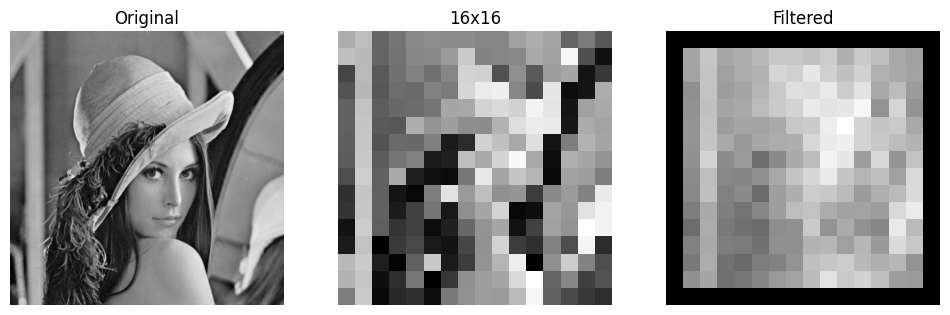

In [51]:
# Compare all images

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(image,cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(resized,cmap="gray")
plt.title("16x16")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(filtered,cmap="gray")
plt.title("Filtered")
plt.axis("off")

plt.show()

In [52]:
print("Original Shape:",image.shape)
print("Resized Shape:",resized.shape)
print("Filtered Shape:",filtered.shape)

Original Shape: (512, 512)
Resized Shape: (16, 16)
Filtered Shape: (16, 16)


In [53]:
cv2.imwrite("resized_image.jpg",resized)

True